In [49]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import Dataset, random_split, DataLoader, dataset

import pathlib
import matplotlib.patches as patches

In [2]:
from data.pets_dataset import OxfordIIITPetDataset, get_class_map

from models import MultiTaskPerceptionModel

In [3]:
multitask_model = MultiTaskPerceptionModel(num_breeds = 37, 
                                           seg_classes = 1, 
                                           in_channels = 3, 
                                           classifier_path = "checkpoints/classifier.pth",
                                           localizer_path  = "checkpoints/localizer.pth",
                                           unet_path       = "checkpoints/unet.pth")
multitask_model.eval()
print("read to go")

classifier loaded!
localizer loaded!
unet loaded!
read to go


In [87]:
train_ratio = 0.8
BATCH_SIZE = 4
mappings = get_class_map(pathlib.Path("oxford-iiit-pet"))

dataset = OxfordIIITPetDataset(root_dir = "oxford-iiit-pet")

train_ds, test_ds = random_split(dataset, [int(train_ratio * len(dataset)), len(dataset)-int(train_ratio * len(dataset))])

train_dl = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size = BATCH_SIZE, shuffle=False)

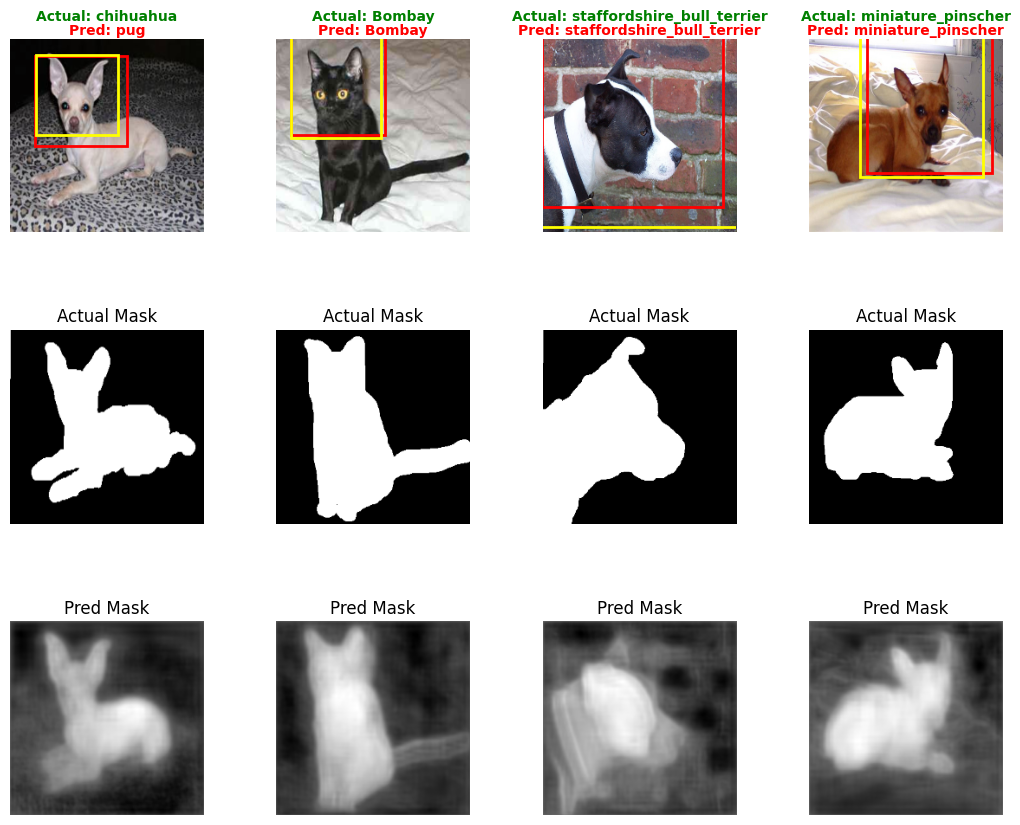

In [96]:
sample = next(iter(train_dl))

sample_image   = sample['image']
sample_classid = sample['class_id']
sample_bbox    = sample['bbox']
sample_mask    = sample['mask']


predictions = multitask_model(sample_image)

class_pred = torch.argmax((torch.softmax(predictions["classification"], dim = 1)), dim = 1)
bbox_pred  = predictions['localization']
mask_pred  = predictions['segmentation']

# processing for plotting
mean = torch.tensor([0.485, 0.456, 0.406], device=sample_image.device).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225], device=sample_image.device).view(3, 1, 1)
sample_image = sample_image * std + mean

fig, ax = plt.subplots(3, BATCH_SIZE, figsize = (8*1.3, 7*1.3))
for idx in range(BATCH_SIZE):
    ax[0][idx].imshow(sample_image[idx].permute(1,2,0).detach().cpu().numpy()) 
    # ax[0][idx].set_title(f"Actual: {mappings[sample_classid[idx].item()]}\nPred: {mappings[class_pred[idx].item()]}")
    ax[0][idx].set_title("")  

    ax[0][idx].text(0.5, 1.08, f"Actual: {mappings[sample_classid[idx].item()]}",
                transform=ax[0][idx].transAxes,
                ha='center', va='bottom',
                color='green', fontsize=10, fontweight='bold')

    ax[0][idx].text(0.5, 1.01, f"Pred: {mappings[class_pred[idx].item()]}",
                transform=ax[0][idx].transAxes,
                ha='center', va='bottom',
                color='red', fontsize=10, fontweight='bold')

    # Predicted bbox (RED) - convert center -> top-left
    xc, yc, w, h = bbox_pred[idx].squeeze().detach().cpu().numpy()
    _, _, H, W = sample_image.shape

    x = (xc - w / 2) * W
    y = (yc - h / 2) * H
    w = w * W
    h = h * H

    rect_pred = patches.Rectangle(
        (x, y), w, h,
        linewidth=2, edgecolor='r', facecolor='none'
    )
    ax[0][idx].add_patch(rect_pred)

    # Actual bbox (YELLOW)
    xc, yc, w_gt, h_gt = sample_bbox[idx].cpu().numpy()
    x_gt = (xc - w_gt / 2) * W
    y_gt = (yc - h_gt / 2) * H
    w_gt = w_gt * W
    h_gt = h_gt * H

    rect_gt = patches.Rectangle((x_gt, y_gt), w_gt, h_gt,
                                  linewidth=2, edgecolor='Yellow', facecolor='none')
    ax[0][idx].add_patch(rect_gt)  

    ax[1][idx].imshow(sample_mask[idx].permute(1,2,0).detach().cpu().numpy(), cmap = "gray") 
    ax[1][idx].imshow(sample_mask[idx].permute(1,2,0).detach().cpu().numpy(), cmap = "gray") 
    ax[1][idx].set_title("Actual Mask")

    ax[2][idx].imshow(mask_pred[idx].permute(1,2,0).detach().cpu().numpy(), cmap = "gray") 
    ax[2][idx].imshow(mask_pred[idx].permute(1,2,0).detach().cpu().numpy(), cmap = "gray") 
    ax[2][idx].set_title("Pred Mask")

    ax[0][idx].axis("off")
    ax[1][idx].axis("off")
    ax[2][idx].axis("off")

plt.tight_layout()
plt.show()
